# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bhardwaj-ayush03/flyrank-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question
**Question:** Using only the first 14 days of a month, which pages are most likely to show a sustained drop in daily impressions over the next 17 days?

**Decision supported:** A content owner reviews the top 20-50 pages per cycle and decides refresh, protect or monitor. This is decision-support ranking, not a causal claim about refreshes.

## 2. Data
Release `flyrank_pseudonymized_warehouse_release_v20260703`, table `fact_content_daily_performance`, partition month=2026-03 only. Rows with GSC data available only. Pages need at least 100 impressions in days 1-14. Excluded: pages below that threshold (too little signal), rows without GSC data. June 2026 was not touched.

In [2]:
!pip -q install huggingface_hub duckdb
from google.colab import userdata
from huggingface_hub import HfApi, snapshot_download
import duckdb, numpy as np, pandas as pd

tok = userdata.get("HF_TOKEN").strip().strip('"').strip("'")
print("token belongs to HF user:", HfApi().whoami(token=tok)["name"])

path = snapshot_download("FlyRank/internship-warehouse", repo_type="dataset", token=tok,
        allow_patterns=["fact_content_daily_performance/month=2026-03/*"])
con = duckdb.connect()
con.execute(f"CREATE TABLE m AS SELECT * FROM read_parquet('{path}/fact_content_daily_performance/month=2026-03/*.parquet')")

# grain check
print(con.execute("""SELECT COUNT(*) AS n,
  COUNT(DISTINCT (report_date, client_hash_id, content_hash_id)) AS n_distinct FROM m""").df())

token belongs to HF user: ayushbh03


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

         n  n_distinct
0  9841378     9841378


## 3. Methodology
Label: declined_later = average daily impressions in days 15-31 are at least 30% below days 1-14 (proxy label, windows do not overlap). Pages with no rows after day 14 count as 0 impressions. Features come only from days 1-14: early_impr, early_ctr, early_avg_pos, early_active_days, early_momentum. Baseline: rank by log10(early_impr). Split: one client-holdout (GroupShuffleSplit, 70/30). Trend labels and outcome-window columns are never features.

In [3]:
df = con.execute("""
WITH w AS (
  SELECT client_hash_id AS client_id, content_hash_id AS content_id,
    SUM(gsc_impressions) FILTER (WHERE CAST(report_date AS DATE) <= DATE '2026-03-14') AS early_impr,
    SUM(gsc_clicks)      FILTER (WHERE CAST(report_date AS DATE) <= DATE '2026-03-14') AS early_clicks,
    AVG(gsc_avg_position) FILTER (WHERE CAST(report_date AS DATE) <= DATE '2026-03-14') AS early_avg_pos,
    COUNT(DISTINCT report_date) FILTER (WHERE CAST(report_date AS DATE) <= DATE '2026-03-14' AND gsc_impressions > 0) AS early_active_days,
    SUM(gsc_impressions) FILTER (WHERE CAST(report_date AS DATE) BETWEEN DATE '2026-03-01' AND DATE '2026-03-07') AS f7,
    SUM(gsc_impressions) FILTER (WHERE CAST(report_date AS DATE) BETWEEN DATE '2026-03-08' AND DATE '2026-03-14') AS l7,
    SUM(gsc_impressions) FILTER (WHERE CAST(report_date AS DATE) >= DATE '2026-03-15') AS late_impr
  FROM m WHERE gsc_data_available IS TRUE
  GROUP BY 1, 2
)
SELECT client_id, content_id, early_impr,
  early_clicks / NULLIF(early_impr, 0) AS early_ctr,
  early_avg_pos, early_active_days,
  (l7 - f7) / NULLIF(f7, 0) AS early_momentum,
  (COALESCE(late_impr, 0) / 17.0) <= 0.7 * (early_impr / 14.0) AS declined_later
FROM w WHERE early_impr >= 100
""").df()

df["declined_later"] = df["declined_later"].astype(int)
df[["early_ctr", "early_avg_pos", "early_momentum"]] = df[["early_ctr", "early_avg_pos", "early_momentum"]].fillna(df[["early_ctr", "early_avg_pos", "early_momentum"]].median())
print(df.shape, "clients:", df.client_id.nunique(), "| base rate:", round(df.declined_later.mean(), 3))

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score
FEATS = ["early_impr", "early_ctr", "early_avg_pos", "early_active_days", "early_momentum"]
X, y = df[FEATS], df["declined_later"]
tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42).split(X, y, groups=df["client_id"]))
Xtr, Xte, ytr, yte = X.iloc[tr], X.iloc[te], y.iloc[tr], y.iloc[te]
print("train clients:", df.iloc[tr].client_id.nunique(), "| test clients:", df.iloc[te].client_id.nunique(),
      "| test base rate:", round(yte.mean(), 3))

def p_at_k(y_true, score, k):
    idx = np.argsort(-np.asarray(score), kind="stable")[:k]
    return float(np.asarray(y_true)[idx].mean())

# baseline: no label-derived inputs, just visibility
base_score = np.log10(Xte["early_impr"])
base = {"AUC": roc_auc_score(yte, base_score), "P@20": p_at_k(yte, base_score, 20), "P@50": p_at_k(yte, base_score, 50)}
print("BASELINE (held-out clients):", {k: round(v, 3) for k, v in base.items()})

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(75526, 8) clients: 37 | base rate: 0.254
train clients: 25 | test clients: 12 | test base rate: 0.295
BASELINE (held-out clients): {'AUC': np.float64(0.464), 'P@20': 0.25, 'P@50': 0.26}


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

models = {
    "tree_depth3": DecisionTreeClassifier(max_depth=3, random_state=42),
    "logistic": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "grad_boost": HistGradientBoostingClassifier(max_depth=3, max_iter=150, learning_rate=0.05, random_state=42),
}
rows = [{"model": "baseline_log_impr", "AUC": base["AUC"], "P@20": base["P@20"], "P@50": base["P@50"], "tied_at_50": 0}]
scores = {}
for name, mdl in models.items():
    mdl.fit(Xtr, ytr)
    s = mdl.predict_proba(Xte)[:, 1]
    scores[name] = s
    thr = np.sort(s)[::-1][49]
    rows.append({"model": name, "AUC": roc_auc_score(yte, s), "P@20": p_at_k(yte, s, 20),
                 "P@50": p_at_k(yte, s, 50), "tied_at_50": int((s == thr).sum())})
res = pd.DataFrame(rows).round(3)
res["test_base_rate"] = round(yte.mean(), 3)
print(res.to_string(index=False))

# leak trap: add one outcome-window column, watch the score jump, then discard it
late = con.execute("""SELECT client_hash_id AS client_id, content_hash_id AS content_id,
  SUM(gsc_impressions) AS late_impr FROM m
  WHERE gsc_data_available IS TRUE AND CAST(report_date AS DATE) >= DATE '2026-03-15' GROUP BY 1, 2""").df()
d2 = df.merge(late, on=["client_id", "content_id"], how="left").fillna({"late_impr": 0})
d2["leak_ratio"] = (d2["late_impr"] / 17) / (d2["early_impr"] / 14)
lk = DecisionTreeClassifier(max_depth=3, random_state=42).fit(d2.iloc[tr][FEATS + ["leak_ratio"]], ytr)
ls = lk.predict_proba(d2.iloc[te][FEATS + ["leak_ratio"]])[:, 1]
print("LEAKY (do not use):", {"AUC": round(roc_auc_score(yte, ls), 3), "P@50": round(p_at_k(yte, ls, 50), 3)})
print("leak_ratio removed; honest numbers are the table above.")

            model   AUC  P@20  P@50  tied_at_50  test_base_rate
baseline_log_impr 0.464  0.25  0.26           0           0.295
      tree_depth3 0.635  0.95  0.88         216           0.295
         logistic 0.569  0.20  0.18           1           0.295
       grad_boost 0.733  0.95  0.94           1           0.295
LEAKY (do not use): {'AUC': np.float64(1.0), 'P@50': 1.0}
leak_ratio removed; honest numbers are the table above.


Honest table above: all models and the baseline are scored on the same held-out clients (12 test clients). Compare against the test base rate, not only the full-data base rate. tied_at_50 shows how many pages share the score at rank 50, so Precision@50 is noisy when it is large. The leak trap (leak_ratio from days 15-31) pushed the score to near-perfect, which proves the check works. It was removed and is not in any reported number.

## 5. Limitations

*What this work cannot claim.*

- Observed, directional, decision-support only. No causal claim: nothing here shows that a refresh would recover impressions.
- The label is a proxy: a 30% drop in average daily impressions, days 15-31 vs days 1-14 of one month (17-day outcome window). It cannot separate real decline from seasonality, consolidation, SERP or AI click loss, or noise.
- One month (2026-03), one client-holdout split (25 train / 12 test clients). Precision@20 and @50 are computed on few rows and are noisy; results may shift with a different split. AUC is the steadier number.
- Unbalanced panel: client mix differs between train and test (test base rate 0.295 vs 0.254 overall). All comparisons use the test base rate.
- The signal is likely dominated by early momentum (trend continuation). Not tested on a later sealed month.
- Baseline (log impressions) is a simple visibility rule; it scored at chance on held-out clients, so the model's lift is measured against a weak baseline.
- Two of the 12 held-out clients supply 16 of the top 20 pages, and the top 50 come from 8 clients (largest share 40%). Precision@20/50 therefore reflects a few clients' behaviour.
- All top-50 pages carry the same reason code (momentum_already_falling). The model mainly detects trend continuation; permutation importance: early_momentum 0.166 AUC drop vs at most 0.045 for the other four features.
- Pages with no rows after day 14 are counted as 0 impressions in the outcome window; some may reflect missing data rather than a real drop.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [5]:
from sklearn.inspection import permutation_importance

gb = models["grad_boost"]
te_df = df.iloc[te].copy()
te_df["score"] = scores["grad_boost"]
te_df["client_idx"] = te_df["client_id"].astype("category").cat.codes  # anonymous index, no hashes shown
te_df = te_df.sort_values("score", ascending=False).reset_index(drop=True)
te_df["rank"] = te_df.index + 1

def reason(r):
    if r["early_momentum"] <= -0.3: return "momentum_already_falling"
    if r["early_avg_pos"] > 10:     return "low_position_fragile"
    if r["early_impr"] >= te_df["early_impr"].quantile(0.9): return "high_visibility_at_risk"
    return "model_score_only"

def action(r):
    if r["rank"] <= 20: return "refresh_review"
    if r["rank"] <= 50: return "monitor"
    return "none"

te_df["reason_code"] = te_df.apply(reason, axis=1)
te_df["action"] = te_df.apply(action, axis=1)
low = te_df["score"] <= te_df["score"].quantile(0.2)
te_df.loc[low & (te_df["early_impr"] >= te_df["early_impr"].quantile(0.9)), "action"] = "protect"
te_df["what_would_make_it_wrong"] = "Seasonal dip or a one-off traffic spike in days 1-14; page may recover on its own"

top20 = te_df.head(20)[["rank", "client_idx", "score", "early_impr", "early_avg_pos", "early_momentum",
                        "reason_code", "action", "declined_later"]].round(3)
print(top20.to_string(index=False))
print("\nactions:", te_df["action"].value_counts().to_dict())
print("clients in top 50:", te_df.head(50)["client_idx"].nunique(), "| largest client share of top 50:",
      te_df.head(50)["client_idx"].value_counts(normalize=True).iloc[0].round(2))
print("reason codes in top 50:", te_df.head(50)["reason_code"].value_counts().to_dict())

pi = permutation_importance(gb, Xte, yte, scoring="roc_auc", n_repeats=3, random_state=42)
print("\npermutation importance (AUC drop):", dict(zip(FEATS, pi.importances_mean.round(3))))

 rank  client_idx  score  early_impr  early_avg_pos  early_momentum              reason_code         action  declined_later
    1           2  0.963       103.0          5.251          -0.980 momentum_already_falling refresh_review               1
    2           8  0.959       119.0          5.744          -0.974 momentum_already_falling refresh_review               1
    3           5  0.957       645.0          2.302          -0.997 momentum_already_falling refresh_review               1
    4           0  0.956       105.0          1.072          -0.846 momentum_already_falling refresh_review               1
    5           2  0.955       114.0          9.128          -0.982 momentum_already_falling refresh_review               1
    6           2  0.953       131.0          8.360          -0.992 momentum_already_falling refresh_review               1
    7           8  0.950       112.0         21.826          -0.991 momentum_already_falling refresh_review               1
    8   

Playbook: top 20 by model score = refresh_review (a content owner reads the page and decides), ranks 21-50 = monitor, lowest-risk high-visibility pages = protect. Each top-20 row carries a reason code and a "what would make it wrong" line. These are review priorities, not predictions that a refresh will help.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

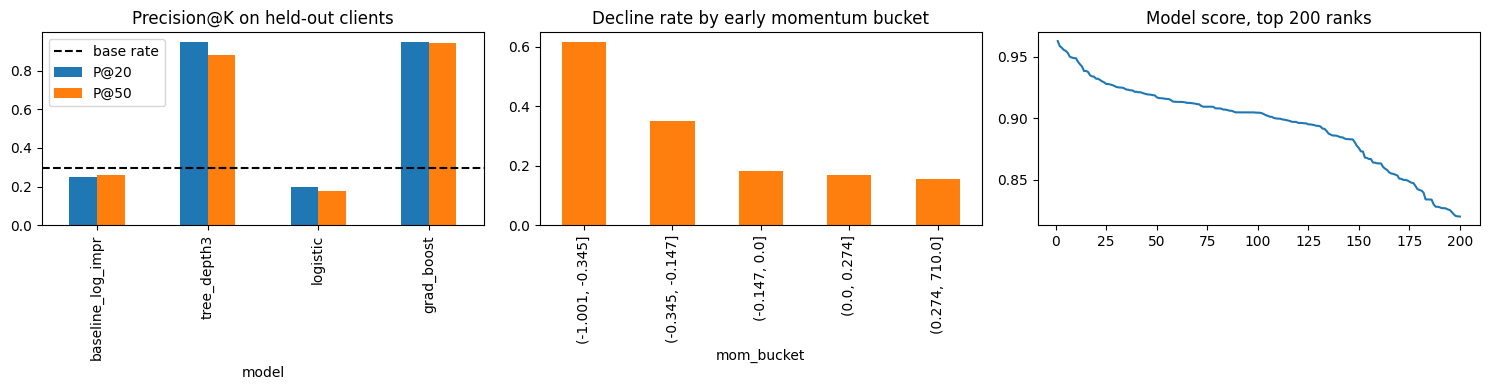

{
 "n_pages": 75526,
 "n_clients": 37,
 "base_rate_all": 0.254,
 "base_rate_test": 0.295,
 "results": [
  {
   "model": "baseline_log_impr",
   "AUC": 0.464,
   "P@20": 0.25,
   "P@50": 0.26,
   "tied_at_50": 0,
   "test_base_rate": 0.295
  },
  {
   "model": "tree_depth3",
   "AUC": 0.635,
   "P@20": 0.95,
   "P@50": 0.88,
   "tied_at_50": 216,
   "test_base_rate": 0.295
  },
  {
   "model": "logistic",
   "AUC": 0.569,
   "P@20": 0.2,
   "P@50": 0.18,
   "tied_at_50": 1,
   "test_base_rate": 0.295
  },
  {
   "model": "grad_boost",
   "AUC": 0.733,
   "P@20": 0.95,
   "P@50": 0.94,
   "tied_at_50": 1,
   "test_base_rate": 0.295
  }
 ],
 "top20_actions": {
  "refresh_review": 20
 }
}
{Interval(-1.001, -0.345, closed='right'): 0.617, Interval(-0.345, -0.147, closed='right'): 0.352, Interval(-0.147, 0.0, closed='right'): 0.182, Interval(0.0, 0.274, closed='right'): 0.169, Interval(0.274, 710.0, closed='right'): 0.156}


In [6]:
import matplotlib.pyplot as plt, json

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
res.set_index("model")[["P@20", "P@50"]].plot.bar(ax=ax[0]); ax[0].axhline(yte.mean(), color="k", ls="--", label="base rate")
ax[0].set_title("Precision@K on held-out clients"); ax[0].legend()

te_df["mom_bucket"] = pd.qcut(te_df["early_momentum"], 5, duplicates="drop")
te_df.groupby("mom_bucket", observed=True)["declined_later"].mean().plot.bar(ax=ax[1], color="tab:orange")
ax[1].set_title("Decline rate by early momentum bucket")

ax[2].plot(te_df["rank"].head(200), te_df["score"].head(200)); ax[2].set_title("Model score, top 200 ranks")
plt.tight_layout(); plt.show()

paper_numbers = {"n_pages": len(df), "n_clients": int(df.client_id.nunique()), "base_rate_all": round(df.declined_later.mean(), 3),
                 "base_rate_test": round(yte.mean(), 3), "results": res.to_dict("records"),
                 "top20_actions": te_df.head(20)["action"].value_counts().to_dict()}
print(json.dumps(paper_numbers, indent=1, default=float))
print(te_df.groupby("mom_bucket", observed=True)["declined_later"].mean().round(3).to_dict())

## ML-12: Demo, social post, employer summary

**5-minute demo outline**
1. (0:00) The decision: a content owner has time to review 20 pages this cycle. Which 20?
2. (0:45) Data: one month of anonymized search data, 75,526 pages across 37 clients, features from days 1-14, outcome from days 15-31.
3. (1:30) Label and split: a 30% drop in daily impressions; models scored on clients they never saw.
4. (2:15) Result: baseline at chance (AUC 0.46); gradient boosting reaches AUC 0.73 and Precision@50 0.94 vs a 0.295 base rate.
5. (3:15) Leak trap: adding one outcome-window column gives a perfect 1.0; I removed it and report the honest number.
6. (4:00) Ranked review queue with reason codes, plus the limits: proxy label, one month, trend-continuation signal.
7. (4:45) What I would do next: a longer window and the sealed June month.

**Social post**
I built a ranked "which pages to review first" model on real search data from the FlyRank ML Internship. Scored on clients it had never seen, it reached Precision@50 of 0.94 vs a 0.295 base rate. I also planted a deliberate leak to show what a fake 1.0 looks like, then removed it. The catch: the signal is mostly "pages already falling keep falling". Observed, directional, decision-support only. Paper and code in my repo.

**Employer summary (3 sentences)**
I built and validated a page-level content review ranking on real multi-client search data, using a non-overlapping feature/outcome window and client-holdout evaluation. Gradient boosting reached AUC 0.73 and Precision@50 0.94 against a 0.295 base rate, while a simple visibility baseline scored at chance. I documented a leakage check, the dominant early-momentum signal and the limits of a proxy label, and shipped the work as a public research paper.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
